<center>
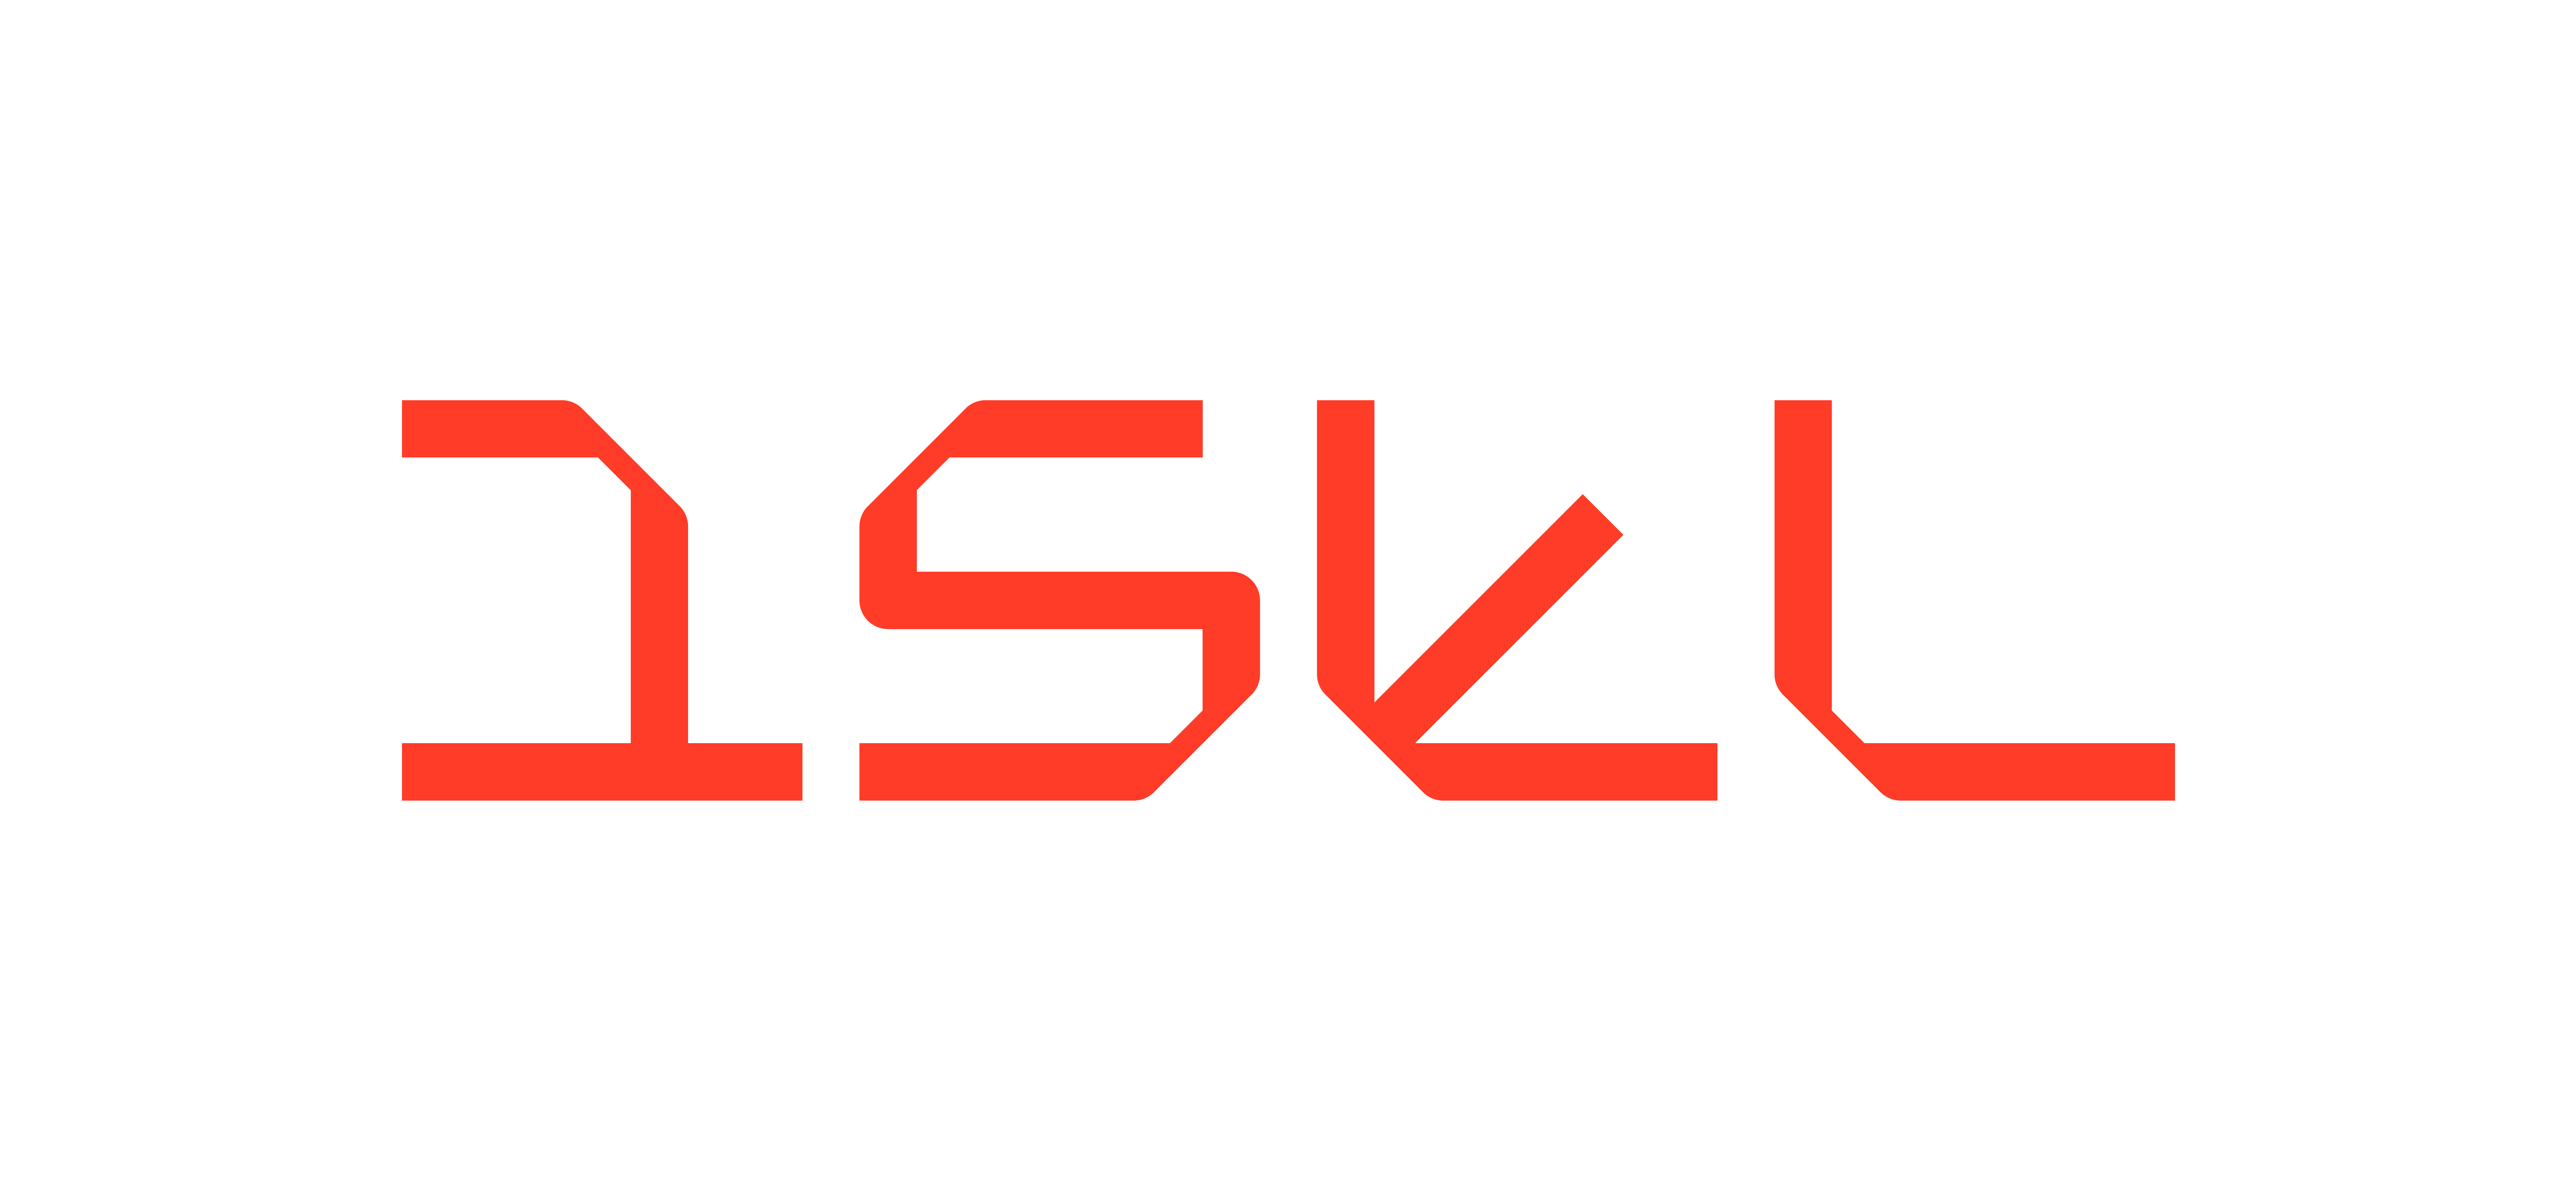
</center>

## <center><b>Instituto Superior de Engenharia de Lisboa<b></center>
### <center>Licenciatura em Engenharia Informática e Multimédia</center>
### <center><b>Processamento de Imagem e Visão</b><br>1º Semestre de 2025/2026</center>
#### <center><b>Trabalho Práctico 2</b></center>

<a id="inicio"></a>

<hr>
<br>
<center>Trabalho realizado por:<br>
• 46346 Inês Silva<br>
• 50274 Joana Araújo </center>
<br>

<br>

<center><b>Turma 51N ▪ Docente Nuno Silva</b></center><br>
<hr>

### <center>**Introdução**</center> <a class="anchor" id="chapter1"></a>

In [6]:
# importação das bibliotecas

import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from collections import Counter

Frame capturado: (480, 640, 3)


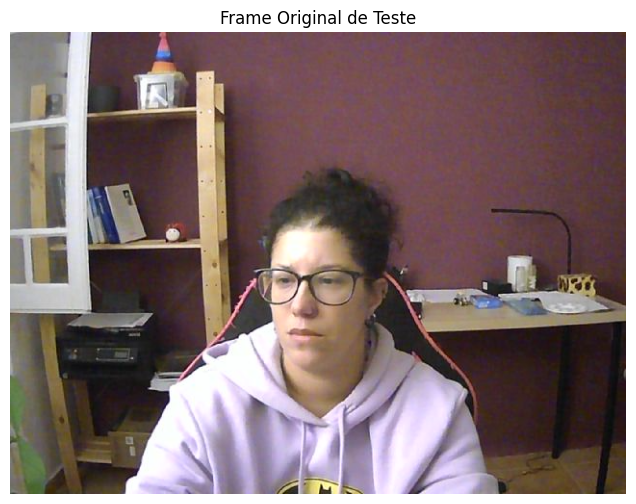

In [ ]:
# Capturar um frame da webcam para experiência

cap = cv.VideoCapture(0)
ret, frame_test = cap.read()
cap.release()

if ret:
    # Espelha o frame para ser mais intuitivo
    frame_test = cv.flip(frame_test, 1)  
    print(f"Frame capturado: {frame_test.shape}")
    
    plt.figure(figsize=(10, 6))
    plt.imshow(cv.cvtColor(frame_test, cv.COLOR_BGR2RGB))
    plt.title("Frame Original de Teste")
    plt.axis('off')
    plt.show()
else:
    print("Erro ao capturar frame da webcam")

In [36]:
frame_test.shape[1]

640

In [ ]:
# Análise de Histograma
# Identificar cor dominante do fundo

def analyze_frame_colors(frame, n_clusters=5, show_analysis=True):
    """
    Analisa as cores predominantes no frame
    
    Retorna:
    - Cores dominantes (BGR)
    - Percentagem de cada cor
    - Histogramas HSV
    """
    
    # Redimensionar para acelerar (opcional)
    small_frame = cv.resize(frame, (frame.shape[1]//4, frame.shape[0]//4))
    
    # Converter para HSV
    hsv = cv.cvtColor(frame, cv.COLOR_BGR2HSV)
    
    # Calcular histogramas de cada canal
    h_hist = cv.calcHist([hsv], [0], None, [180], [0, 180])
    s_hist = cv.calcHist([hsv], [1], None, [256], [0, 256])
    v_hist = cv.calcHist([hsv], [2], None, [256], [0, 256])
    
    # Encontrar picos nos histogramas
    h_peaks = np.argsort(h_hist.flatten())[-3:]  # Top 3 Hues
    s_peaks = np.argsort(s_hist.flatten())[-3:]  # Top 3 Saturations
    
    # Análise de cor dominante usando regiões da imagem
    # Dividir frame em 9 regiões (3x3 grid)
    h, w = frame.shape[:2]
    regions = {
        'top_left': frame[0:h//3, 0:w//3],
        'top_center': frame[0:h//3, w//3:2*w//3],
        'top_right': frame[0:h//3, 2*w//3:w],
        'center_left': frame[h//3:2*h//3, 0:w//3],
        'center': frame[h//3:2*h//3, w//3:2*w//3],
        'center_right': frame[h//3:2*h//3, 2*w//3:w],
        'bottom_left': frame[2*h//3:h, 0:w//3],
        'bottom_center': frame[2*h//3:h, w//3:2*w//3],
        'bottom_right': frame[2*h//3:h, 2*w//3:w]
    }
    
    # Calcular cor média de cada região
    region_colors = {}
    for name, region in regions.items():
        mean_color = region.mean(axis=0).mean(axis=0)  # BGR
        region_colors[name] = mean_color
    
    # Identificar regiões de "fundo" (assumir que bordas = fundo)
    background_regions = ['top_left', 'top_center', 'top_right', 
                          'center_left', 'center_right',
                          'bottom_left', 'bottom_center', 'bottom_right']
    
    background_colors = [region_colors[r] for r in background_regions]
    dominant_bg_color = np.median(background_colors, axis=0)
    
    if show_analysis:
        fig = plt.figure(figsize=(16, 10))
        
        # Grid de layout
        gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)
        
        # Frame original
        ax1 = fig.add_subplot(gs[0, :2])
        ax1.imshow(cv.cvtColor(frame, cv.COLOR_BGR2RGB))
        ax1.set_title("Frame Original", fontsize=14, fontweight='bold')
        ax1.axis('off')
        
        # Grid de regiões
        ax2 = fig.add_subplot(gs[0, 2:])
        grid_vis = frame.copy()
        cv.line(grid_vis, (w//3, 0), (w//3, h), (255, 255, 255), 2)
        cv.line(grid_vis, (2*w//3, 0), (2*w//3, h), (255, 255, 255), 2)
        cv.line(grid_vis, (0, h//3), (w, h//3), (255, 255, 255), 2)
        cv.line(grid_vis, (0, 2*h//3), (w, 2*h//3), (255, 255, 255), 2)
        ax2.imshow(cv.cvtColor(grid_vis, cv.COLOR_BGR2RGB))
        ax2.set_title("Divisão em Regiões", fontsize=14, fontweight='bold')
        ax2.axis('off')
        
        # Histograma H
        ax3 = fig.add_subplot(gs[1, 0])
        ax3.plot(h_hist, color='red', linewidth=2)
        ax3.set_title("Histograma Hue")
        ax3.set_xlabel("Hue (0-179)")
        ax3.set_xlim([0, 180])
        ax3.grid(True, alpha=0.3)
        # Marcar picos
        for peak in h_peaks:
            ax3.axvline(x=peak, color='green', linestyle='--', alpha=0.7)
        
        # Histograma S
        ax4 = fig.add_subplot(gs[1, 1])
        ax4.plot(s_hist, color='green', linewidth=2)
        ax4.set_title("Histograma Saturation")
        ax4.set_xlabel("Saturation (0-255)")
        ax4.set_xlim([0, 256])
        ax4.grid(True, alpha=0.3)
        
        # Histograma V
        ax5 = fig.add_subplot(gs[1, 2])
        ax5.plot(v_hist, color='blue', linewidth=2)
        ax5.set_title("Histograma Value")
        ax5.set_xlabel("Value (0-255)")
        ax5.set_xlim([0, 256])
        ax5.grid(True, alpha=0.3)
        
        # Cor dominante de fundo
        ax6 = fig.add_subplot(gs[1, 3])
        color_square = np.ones((100, 100, 3), dtype=np.uint8)
        color_square[:, :] = dominant_bg_color.astype(np.uint8)
        ax6.imshow(cv.cvtColor(color_square, cv.COLOR_BGR2RGB))
        ax6.set_title(f"Cor Dominante Fundo\nBGR: {dominant_bg_color.astype(int)}")
        ax6.axis('off')
        
        # Mapa de cores das regiões
        ax7 = fig.add_subplot(gs[2, :])
        region_vis = np.zeros((100, 900, 3), dtype=np.uint8)
        for i, (name, color) in enumerate(region_colors.items()):
            region_vis[:, i*100:(i+1)*100] = color.astype(np.uint8)
            
        ax7.imshow(cv.cvtColor(region_vis, cv.COLOR_BGR2RGB))
        ax7.set_title("Cores Médias de Cada Região")
        ax7.set_xticks(np.arange(50, 900, 100))
        ax7.set_xticklabels(list(region_colors.keys()), rotation=45, ha='right')
        ax7.set_yticks([])
        
        plt.show()
    
    return {
        'dominant_bg_color_bgr': dominant_bg_color,
        'h_peaks': h_peaks,
        's_peaks': s_peaks,
        'h_hist': h_hist,
        's_hist': s_hist,
        'v_hist': v_hist,
        'region_colors': region_colors
    }

In [19]:
# Segmentação Baseada em Histograma

def segment_by_background_color(frame, bg_color_bgr, tolerance=30, show_steps=True):
    """
    Segmenta removendo pixels similares à cor de fundo dominante
    
    Parâmetros:
    - bg_color_bgr: cor do fundo em BGR (numpy array)
    - tolerance: tolerância de diferença (0-255)
    """
    
    # Converter cor de fundo para HSV
    bg_color_hsv = cv.cvtColor(np.uint8([[bg_color_bgr]]), cv.COLOR_BGR2HSV)[0][0]
    
    # Converter frame para HSV
    hsv = cv.cvtColor(frame, cv.COLOR_BGR2HSV)
    
    # Criar ranges baseados na cor de fundo ± tolerância
    h_min = int(max(0, bg_color_hsv[0] - tolerance//2))
    h_max = int(min(179, bg_color_hsv[0] + tolerance//2))
    s_min = int(max(0, bg_color_hsv[1] - tolerance))
    s_max = int(min(255, int(bg_color_hsv[1]) + tolerance))
    v_min = int(max(0, bg_color_hsv[2] - tolerance))
    v_max = int(min(255, bg_color_hsv[2] + tolerance))
    
    lower = np.array([h_min, s_min, v_min], dtype=np.uint8)
    upper = np.array([h_max, s_max, v_max], dtype=np.uint8)
    
    # Máscara do fundo
    mask_bg = cv.inRange(hsv, lower, upper)
    
    # Inverter (queremos pessoa)
    mask_person = cv.bitwise_not(mask_bg)
    
    # Limpeza morfológica
    kernel_size = (2,2)
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, kernel_size)
    mask_clean = cv.morphologyEx(mask_person, cv.MORPH_CLOSE, kernel, iterations=2)
    mask_clean = cv.morphologyEx(mask_clean, cv.MORPH_OPEN, kernel, iterations=1)
    
    if show_steps:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        axes[0, 0].imshow(cv.cvtColor(frame, cv.COLOR_BGR2RGB))
        axes[0, 0].set_title("Original")
        axes[0, 0].axis('off')
        
        # Mostrar cor de fundo detectada
        bg_square = np.ones((100, 100, 3), dtype=np.uint8)
        bg_square[:, :] = bg_color_bgr.astype(np.uint8)
        axes[0, 1].imshow(cv.cvtColor(bg_square, cv.COLOR_BGR2RGB))
        axes[0, 1].set_title(f"Cor Fundo Detectada\nHSV: {bg_color_hsv}")
        axes[0, 1].axis('off')
        
        # Ranges usados
        info_text = f"Ranges HSV:\nH: [{h_min}, {h_max}]\nS: [{s_min}, {s_max}]\nV: [{v_min}, {v_max}]"
        axes[0, 2].text(0.1, 0.5, info_text, fontsize=12, family='monospace',
                       verticalalignment='center')
        axes[0, 2].set_title("Parâmetros")
        axes[0, 2].axis('off')
        
        axes[1, 0].imshow(mask_bg, cmap='gray')
        axes[1, 0].set_title("Máscara Fundo")
        axes[1, 0].axis('off')
        
        axes[1, 1].imshow(mask_person, cmap='gray')
        axes[1, 1].set_title("Máscara Invertida")
        axes[1, 1].axis('off')
        
        axes[1, 2].imshow(mask_clean, cmap='gray')
        axes[1, 2].set_title("Após Morfologia")
        axes[1, 2].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    return mask_clean

In [ ]:
# Segmentação por Detecção de Pele
# (Mantém tons de pele, remove resto)

def segment_by_skin_detection(frame, show_steps=True):
    """
    Abordagem inversa: detecta e mantém pixels de pele
    Remove tudo o que NÃO é pele
    """
    
    # Converter para YCrCb (melhor para detecção de pele)
    ycrcb = cv.cvtColor(frame, cv.COLOR_BGR2YCrCb)
    
    # Ranges de tons de pele em YCrCb (mais robusto que HSV)
    lower_skin = np.array([0, 133, 77], dtype=np.uint8)
    upper_skin = np.array([255, 173, 127], dtype=np.uint8)
    
    mask_skin_ycrcb = cv.inRange(ycrcb, lower_skin, upper_skin)
    
    # Também usar HSV como backup
    hsv = cv.cvtColor(frame, cv.COLOR_BGR2HSV)
    lower_skin_hsv = np.array([0, 20, 70], dtype=np.uint8)
    upper_skin_hsv = np.array([20, 255, 255], dtype=np.uint8)
    
    mask_skin_hsv = cv.inRange(hsv, lower_skin_hsv, upper_skin_hsv)
    
    # Combinar ambas as máscaras (OR lógico)
    mask_skin = cv.bitwise_or(mask_skin_ycrcb, mask_skin_hsv)
    
    # Limpeza morfológica agressiva
    kernel_size = (5,5)
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, kernel_size)
    mask_clean = cv.morphologyEx(mask_skin, cv.MORPH_CLOSE, kernel, iterations=3)
    mask_clean = cv.morphologyEx(mask_clean, cv.MORPH_OPEN, kernel, iterations=2)
    
    # Dilatar para capturar corpo completo (não só pele exposta)
    kernel_dilate = cv.getStructuringElement(cv.MORPH_ELLIPSE, (21, 21))
    mask_dilated = cv.dilate(mask_clean, kernel_dilate, iterations=3)
    
    if show_steps:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        axes[0, 0].imshow(cv.cvtColor(frame, cv.COLOR_BGR2RGB))
        axes[0, 0].set_title("Original")
        axes[0, 0].axis('off')
        
        axes[0, 1].imshow(mask_skin_ycrcb, cmap='gray')
        axes[0, 1].set_title("Detecção Pele (YCrCb)")
        axes[0, 1].axis('off')
        
        axes[0, 2].imshow(mask_skin_hsv, cmap='gray')
        axes[0, 2].set_title("Detecção Pele (HSV)")
        axes[0, 2].axis('off')
        
        axes[1, 0].imshow(mask_skin, cmap='gray')
        axes[1, 0].set_title("Máscaras Combinadas")
        axes[1, 0].axis('off')
        
        axes[1, 1].imshow(mask_clean, cmap='gray')
        axes[1, 1].set_title("Após Morfologia")
        axes[1, 1].axis('off')
        
        axes[1, 2].imshow(mask_dilated, cmap='gray')
        axes[1, 2].set_title("Dilatada (corpo completo)")
        axes[1, 2].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    return mask_dilated

In [ ]:
# EXPERIÊNCIA 4: Método Híbrido Inteligente

def segment_hybrid_intelligent(frame, show_steps=True):
    """
    Combina análise de histograma + detecção de pele
    Mais robusto!
    """
    
    # Passo 1: Analisar cores do frame
    analysis = analyze_frame_colors(frame, show_analysis=False)
    bg_color = analysis['dominant_bg_color_bgr']
    
    # Passo 2: Segmentar por cor de fundo
    mask_bg_removal = segment_by_background_color(frame, bg_color, 
                                                   tolerance=50, show_steps=False)
    
    # Passo 3: Detectar pele
    mask_skin = segment_by_skin_detection(frame, show_steps=False)
    
    # Passo 4: Combinar (união)
    mask_combined = cv.bitwise_or(mask_bg_removal, mask_skin)
    
    # Passo 5: Limpeza final
    kernel_size = (5,5)
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, kernel_size)
    mask_final = cv.morphologyEx(mask_combined, cv.MORPH_CLOSE, kernel, iterations=2)
    
    if show_steps:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        axes[0, 0].imshow(cv.cvtColor(frame, cv.COLOR_BGR2RGB))
        axes[0, 0].set_title("Original")
        axes[0, 0].axis('off')
        
        # Cor de fundo detectada
        bg_square = np.ones((100, 100, 3), dtype=np.uint8)
        bg_square[:, :] = bg_color.astype(np.uint8)
        axes[0, 1].imshow(cv.cvtColor(bg_square, cv.COLOR_BGR2RGB))
        axes[0, 1].set_title("Fundo Auto-detectado")
        axes[0, 1].axis('off')
        
        axes[0, 2].imshow(mask_bg_removal, cmap='gray')
        axes[0, 2].set_title("Remoção de Fundo")
        axes[0, 2].axis('off')
        
        axes[1, 0].imshow(mask_skin, cmap='gray')
        axes[1, 0].set_title("Detecção de Pele")
        axes[1, 0].axis('off')
        
        axes[1, 1].imshow(mask_combined, cmap='gray')
        axes[1, 1].set_title("Máscaras Combinadas")
        axes[1, 1].axis('off')
        
        axes[1, 2].imshow(mask_final, cmap='gray')
        axes[1, 2].set_title("Resultado Final")
        axes[1, 2].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    return mask_final

🧪 EXPERIMENTAÇÃO DE SEGMENTAÇÃO
✅ Frame capturado

📊 EXPERIÊNCIA 1: Análise de Cores do Frame
------------------------------------------------------------


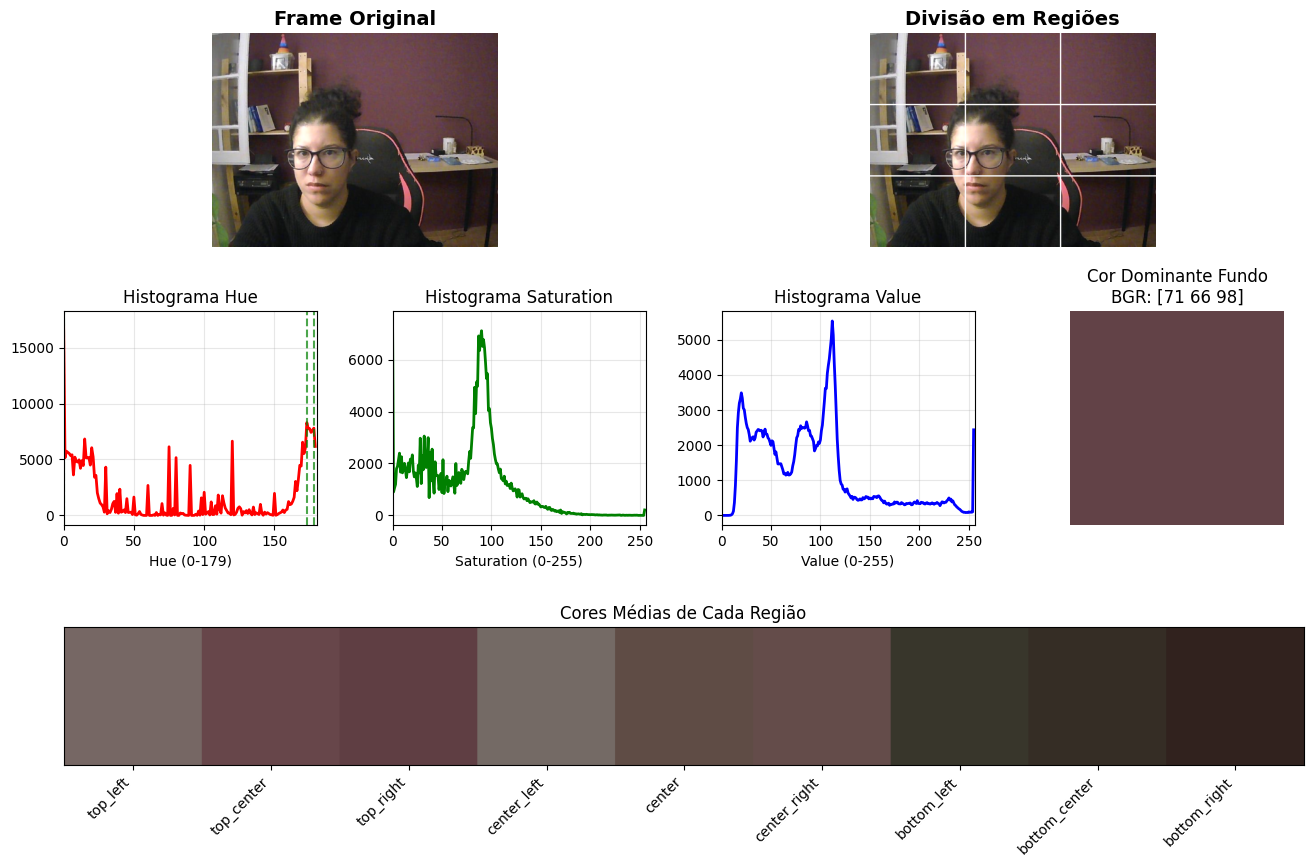


📊 EXPERIÊNCIA 2: Segmentação por Cor de Fundo Auto-detectada
------------------------------------------------------------


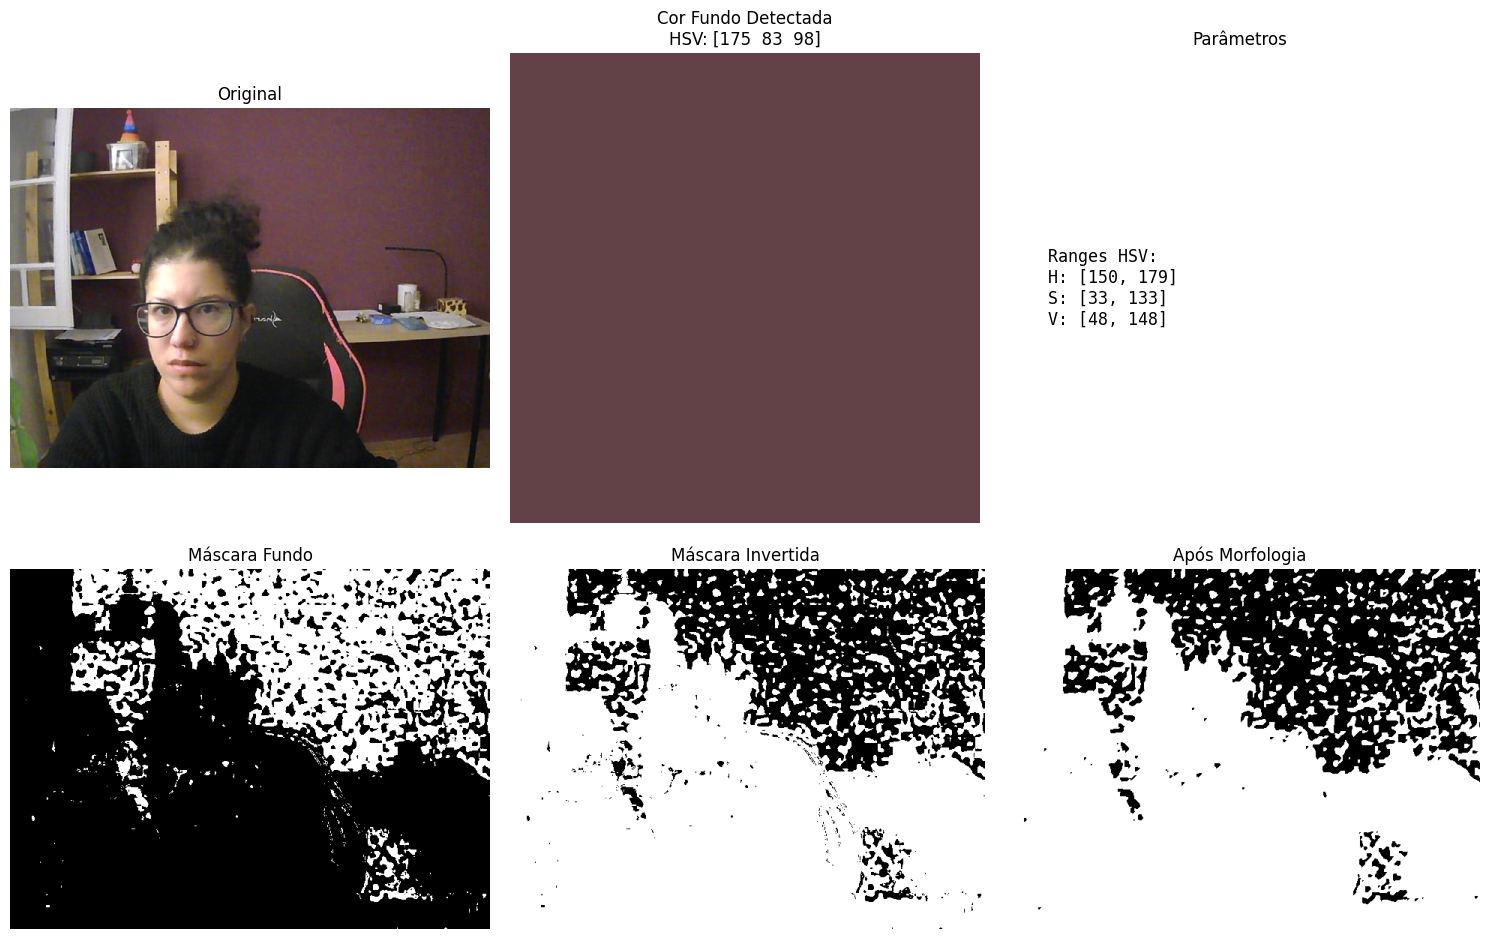


📊 EXPERIÊNCIA 3: Segmentação por Detecção de Pele
------------------------------------------------------------


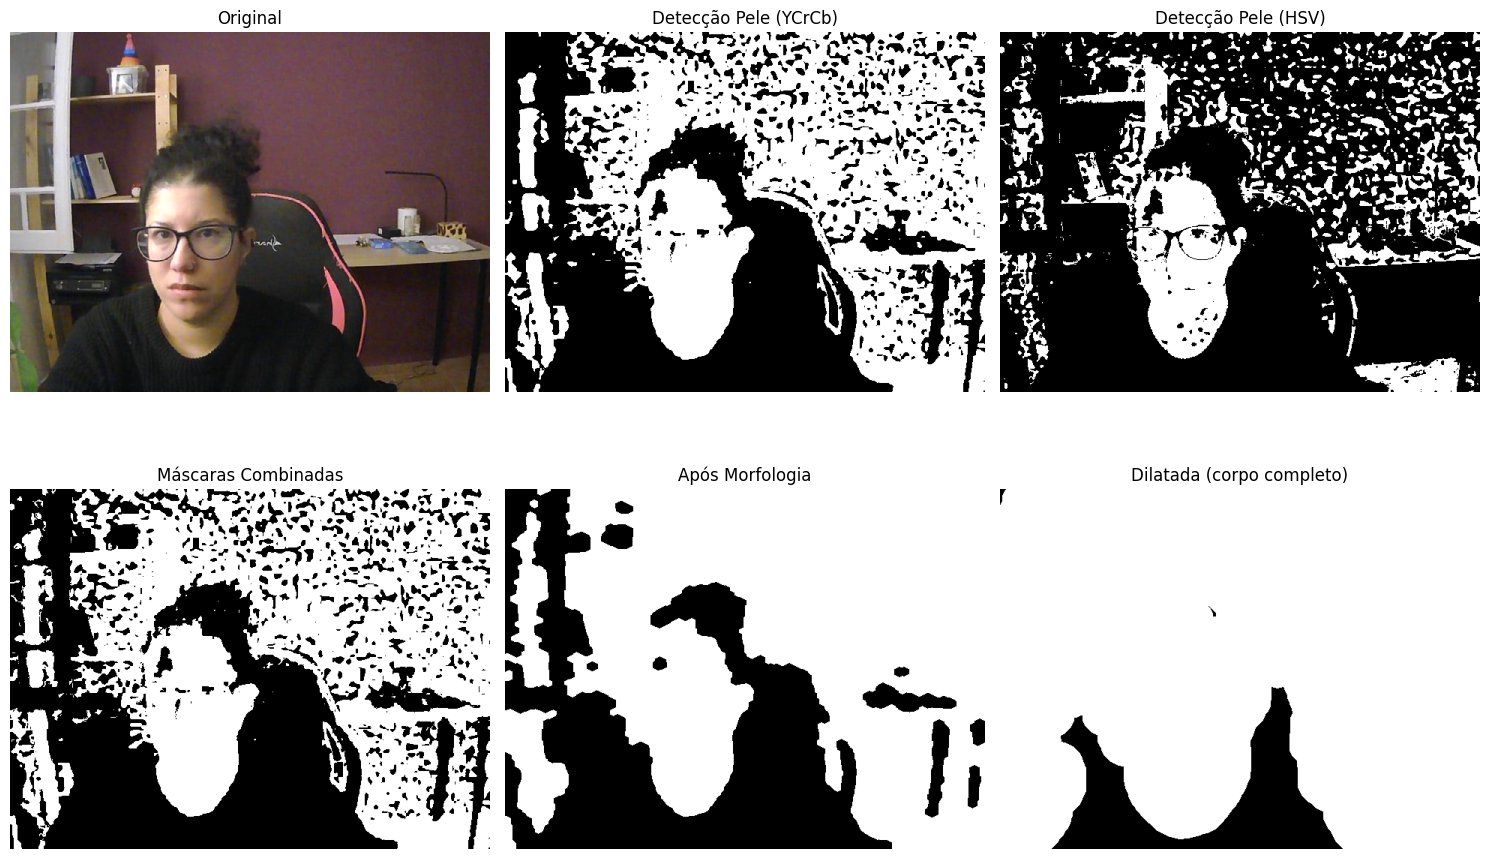


📊 EXPERIÊNCIA 4: Método Híbrido Inteligente
------------------------------------------------------------


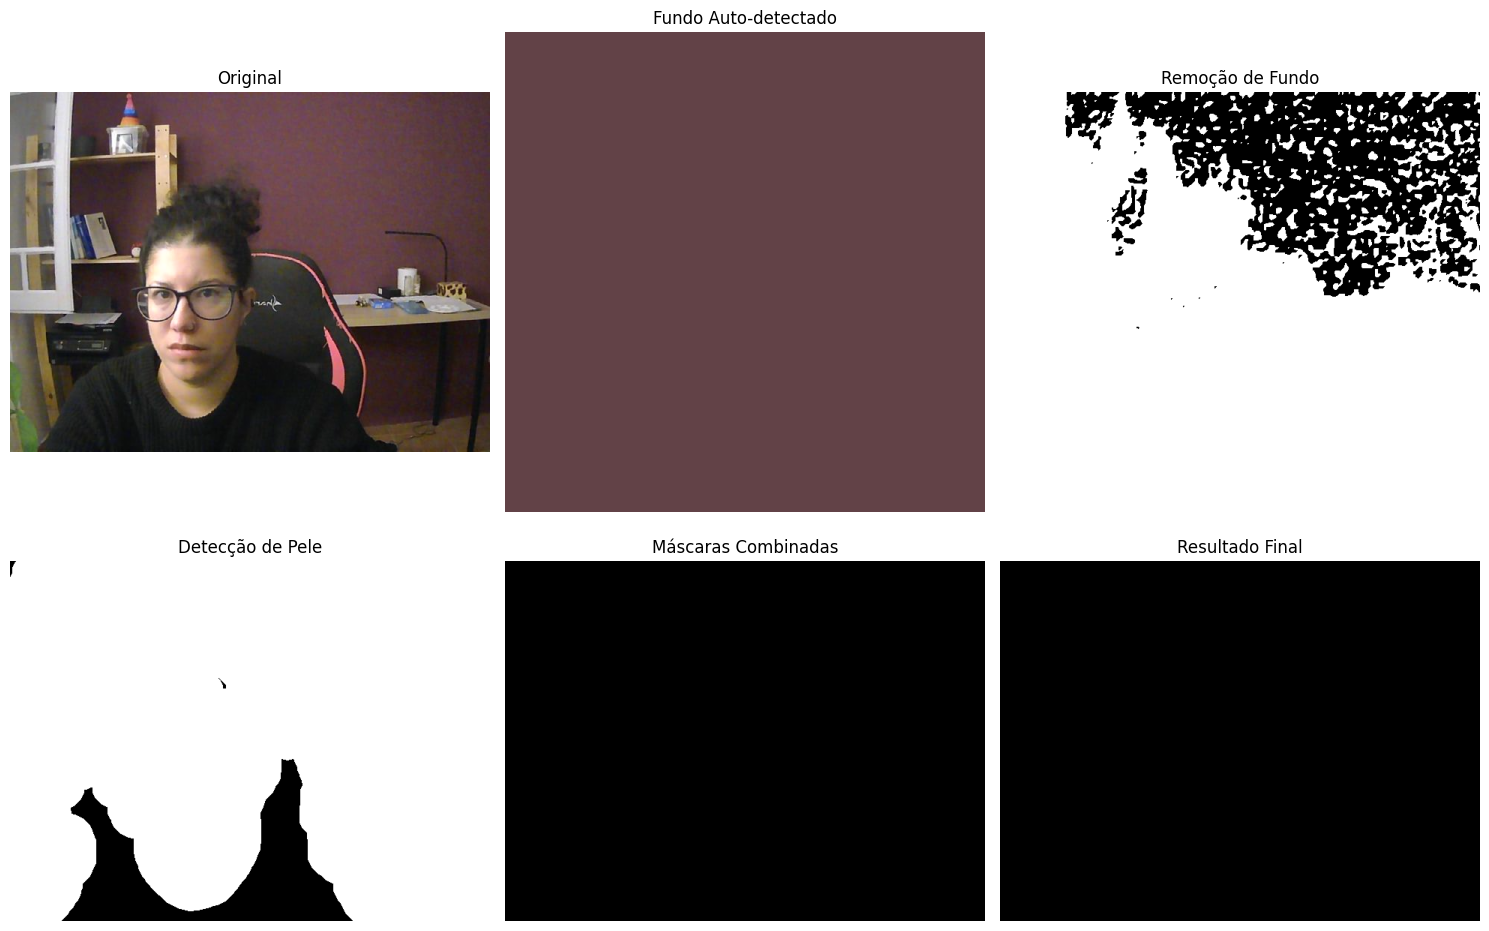


📈 ANÁLISE COMPARATIVA
Método 1 (Cor de Fundo): 73.4% detectado
Método 2 (Detecção Pele): 90.5% detectado
Método 3 (Híbrido):       100.0% detectado

💡 QUAL MÉTODO ESCOLHER?

Analisa os resultados acima e decide:

1. SE o método de COR DE FUNDO funcionou bem (pessoa bem segmentada):
   → Usar esse! É o mais simples e eficaz
   → Ajusta 'tolerance' se necessário (30-60)

2. SE o método de PELE funcionou melhor:
   → Indica que o fundo tem cores variadas
   → Bom para ambientes sem fundo uniforme

3. SE o HÍBRIDO deu melhor resultado:
   → Combina o melhor dos dois mundos
   → Mais robusto mas um pouco mais lento

PRÓXIMO PASSO: Testar em tempo real!



In [ ]:
# TESTES PRÁTICOS


print("="*60)
print("🧪 EXPERIMENTAÇÃO DE SEGMENTAÇÃO")
print("="*60)

# Capturar frame
cap = cv.VideoCapture(0)
ret, frame_test = cap.read()

""" folder = "assets/media/"
frame_test = cv.imread(folder + "img_teste_3.png") """

if ret:
    frame_test = cv.flip(frame_test, 1)
    print("✅ Frame capturado\n")

print("📊 EXPERIÊNCIA 1: Análise de Cores do Frame")
print("-" * 60)
analysis = analyze_frame_colors(frame_test, show_analysis=True)

print("\n📊 EXPERIÊNCIA 2: Segmentação por Cor de Fundo Auto-detectada")
print("-" * 60)
mask_method1 = segment_by_background_color(frame_test, 
                                           analysis['dominant_bg_color_bgr'],
                                           tolerance=50, show_steps=True)

print("\n📊 EXPERIÊNCIA 3: Segmentação por Detecção de Pele")
print("-" * 60)
mask_method2 = segment_by_skin_detection(frame_test, show_steps=True)

print("\n📊 EXPERIÊNCIA 4: Método Híbrido Inteligente")
print("-" * 60)
mask_final = segment_hybrid_intelligent(frame_test, show_steps=True)

cap.release()

# Comparação estatística
print("\n" + "="*60)
print("📈 ANÁLISE COMPARATIVA")
print("="*60)

total_pixels = mask_method1.shape[0] * mask_method1.shape[1]

perc1 = (np.sum(mask_method1 > 0) / total_pixels) * 100
perc2 = (np.sum(mask_method2 > 0) / total_pixels) * 100
perc3 = (np.sum(mask_final > 0) / total_pixels) * 100

print(f"Método 1 (Cor de Fundo): {perc1:.1f}% detectado")
print(f"Método 2 (Detecção Pele): {perc2:.1f}% detectado")
print(f"Método 3 (Híbrido):       {perc3:.1f}% detectado")

print("\n" + "="*60)
print("💡 QUAL MÉTODO ESCOLHER?")
print("="*60)
print("""
Analisa os resultados acima e decide:

1. SE o método de COR DE FUNDO funcionou bem (pessoa bem segmentada):
   → Usar esse! É o mais simples e eficaz
   → Ajusta 'tolerance' se necessário (30-60)

2. SE o método de PELE funcionou melhor:
   → Indica que o fundo tem cores variadas
   → Bom para ambientes sem fundo uniforme

3. SE o HÍBRIDO deu melhor resultado:
   → Combina o melhor dos dois mundos
   → Mais robusto mas um pouco mais lento

PRÓXIMO PASSO: Testar em tempo real!
""")

### <center>**Conclusão**</center> <a class="anchor" id="chapter11"></a>
